In [1]:
import numpy as np
import xarray as xr
import os 
import glob

In [2]:
#Final so far
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["PSCRATCH"], "scheduler_jupyter.json")

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

client = Client(scheduler_file=scheduler_file)
client

<Client: 'tcp://10.249.1.89:8786' processes=12 threads=252, memory=468.93 GiB>

In [3]:
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

# Match all years from 2001 to 2017
file_names = sorted(
    sum(
        [glob.glob(path + f"AR_categorization_{year}*.nc") for year in range(2001, 2018)],
        []
    )
)

In [4]:
ds = xr.open_mfdataset(file_names)
#print(ds)
AR_event_category = ds['AR_event_category']
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 24712, latitude: 241,
                                       longitude: 441)>
dask.array<concatenate, shape=(24712, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [5]:
precip_path = "/pscratch/sd/d/dkamnani/Results_data/training_input_precip_*.nc"
ds_precip = xr.open_mfdataset(precip_path)
print(ds_precip)

<xarray.Dataset>
Dimensions:    (time: 24744, latitude: 481, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... -59.5 -59.75 -60.0
Data variables:
    tp         (time, latitude, longitude) float32 dask.array<chunksize=(1460, 481, 1440), meta=np.ndarray>


In [6]:
ds_precip = ds_precip['tp']

In [7]:
#Convert from meters to mm. 
ds_precip = ds_precip * 1000.0
ds_precip.attrs['units'] = 'mm'

In [8]:
matching_times = np.intersect1d(ds_precip.time.values, AR_event_category.time.values)
ds_precip = ds_precip.sel(time=matching_times)
print(ds_precip)

<xarray.DataArray 'tp' (time: 24620, latitude: 481, longitude: 1440)>
dask.array<getitem, shape=(24620, 481, 1440), dtype=float32, chunksize=(1460, 481, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... -59.5 -59.75 -60.0
Attributes:
    units:    mm


/global/u1/d/dkamnani/.conda/envs/climate_geo/lib/python3.8/site-packages/xarray/core/indexing.py:1379: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [9]:
AR_event_category = AR_event_category.sel(time=matching_times)
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 24620, latitude: 241,
                                       longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [10]:
#Matching array dimension
ds_precip = ds_precip.sel(latitude=slice(60, 0))
ds_precip = ds_precip.assign_coords(
    longitude=(((ds_precip.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_precip = ds_precip.sortby('longitude')

# 3. Select the desired longitude range
ds_precip = ds_precip.sel(longitude=slice(-160, -50))

/global/u1/d/dkamnani/.conda/envs/climate_geo/lib/python3.8/site-packages/xarray/core/indexing.py:1379: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [11]:
print(ds_precip)

<xarray.DataArray 'tp' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=float32, chunksize=(1460, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
Attributes:
    units:    mm


In [12]:
#Teca data 
"""
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2005*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)
"""
# Update path to include all years from 2001 to 2017
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.20*.nc4"

# Open all files and subset by time
teca_data = xr.open_mfdataset(teca_path, combine='by_coords')
teca_data = teca_data["ar_binary_tag"]

# Select years 2001 to 2017
teca_data = teca_data.sel(time=slice("2001-01-01", "2017-12-31"))

print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 149016, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(149016, 721, 1440), dtype=int8, chunksize=(744, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T23:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [13]:
time = ds_precip.time.values
teca_data = teca_data.sel(time  = time)
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(24620, 721, 1440), dtype=int8, chunksize=(124, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [14]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [15]:
# Remap categories: 6 and 7 -> 5
AR_event_category_remap = xr.where(AR_event_category.isin([6, 7]), 5, AR_event_category)

In [16]:
import numpy as np
import xarray as xr

# --- 1. Mask precip by AR presence ---
precip_ar = ds_precip.where(teca_data == 1)

# --- 2. Define AR categories (1–16) ---
co_categories = np.arange(1, 6)
precip_distributions = []

for cat in co_categories:
    print(cat)
    # Mask precip where the category = cat
    cat_precip = precip_ar.where(AR_event_category == cat)
    
    # Flatten + drop NaNs
    values = cat_precip.values.flatten()
    values = values[~np.isnan(values)]
    values = values[values > 0]
    
    precip_distributions.append(values)

# precip_distributions is now a list of arrays, one per category



1
2
3
4
5


In [17]:
print(precip_distributions)

[array([ 1.166439  ,  0.87246895,  0.556612  , ..., 11.013365  ,
        9.346962  ,  4.988909  ], dtype=float32), array([0.24590492, 0.52871704, 6.6741943 , ..., 1.8024445 , 0.04420281,
       0.14762878], dtype=float32), array([2.5290012, 3.1169412, 0.6394386, ..., 3.014803 , 2.7058125,
       2.3517609], dtype=float32), array([0.34503937, 3.5615444 , 3.9280415 , ..., 0.4407406 , 0.33431053,
       0.26521683], dtype=float32), array([21.420336  , 20.53199   , 20.138027  , ...,  0.545454  ,
        0.55274963,  0.508976  ], dtype=float32)]


In [18]:
import numpy as np

# Save
np.save("precip_distributions.npy", precip_distributions, allow_pickle=True)

# Load back
loaded_precip_distributions = np.load("precip_distributions.npy", allow_pickle=True)

print(type(loaded_precip_distributions))  # <class 'numpy.ndarray'>
print(type(loaded_precip_distributions[0]))  # <class 'numpy.ndarray'>


/global/u1/d/dkamnani/.conda/envs/climate_geo/lib/python3.8/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## Seasonally

In [20]:
import numpy as np
import xarray as xr
import pandas as pd

# --- 1. Mask precip by AR presence ---
precip_ar = ds_precip.where(teca_data == 1)

# --- 2. Define AR categories (1–7 here) ---
co_categories = np.arange(1, 6)

# --- 3. Define seasons ---
season_names = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}

# --- 4. Collect results ---
seasonal_distributions = {}

for season in ["DJF", "MAM", "JJA", "SON"]:
    print(season)
    precip_distributions = []
    # Select times for this season
    season_mask = [season_names[pd.Timestamp(t).month] == season 
                   for t in precip_ar["time"].values]
    precip_season = precip_ar.isel(time=season_mask)
    category_season = AR_event_category.isel(time=season_mask)
    
    for cat in co_categories:
        print(cat)
        # Mask precip where the category = cat
        cat_precip = precip_season.where(category_season == cat)
        
        # Flatten + drop NaNs
        values = cat_precip.values.flatten()
        values = values[~np.isnan(values)]
        values = values[values > 0]
        
        precip_distributions.append(values)
    
    seasonal_distributions[season] = precip_distributions


DJF
1
2
3
4
5
MAM
1
2
3
4
5
JJA
1
2
3
4
5
SON
1
2
3
4
5


In [21]:
print(seasonal_distributions)

{'DJF': [array([ 1.166439  ,  0.87246895,  0.556612  , ..., 11.013365  ,
        9.346962  ,  4.988909  ], dtype=float32), array([0.24590492, 0.52871704, 6.6741943 , ..., 1.8024445 , 0.04420281,
       0.14762878], dtype=float32), array([2.5290012, 3.1169412, 0.6394386, ..., 3.014803 , 2.7058125,
       2.3517609], dtype=float32), array([0.34503937, 3.5615444 , 3.9280415 , ..., 0.4407406 , 0.33431053,
       0.26521683], dtype=float32), array([21.420336  , 20.53199   , 20.138027  , ...,  0.545454  ,
        0.55274963,  0.508976  ], dtype=float32)], 'MAM': [array([6.2999725 , 5.9781075 , 5.7030206 , ..., 0.5021095 , 0.6849289 ,
       0.00944138], dtype=float32), array([6.4424515 , 6.7578793 , 7.5634007 , ..., 0.03519058, 0.10128022,
       0.10128022], dtype=float32), array([3.2469752 , 2.936268  , 2.832842  , ..., 0.07123947, 0.07467269,
       0.05235672], dtype=float32), array([0.64587593, 0.72140694, 0.80294615, ..., 0.086689  , 0.03433228,
       0.03347397], dtype=float32), arra

In [22]:
import pandas as pd

all_records = []

for season, cat_arrays in seasonal_distributions.items():
    for cat, arr in enumerate(cat_arrays, start=1):  # category numbers 1–7
        df_temp = pd.DataFrame({
            "precip": arr,
            "season": season,
            "category": cat
        })
        all_records.append(df_temp)

# Concatenate into one DataFrame
df_out = pd.concat(all_records, ignore_index=True)

# Save to CSV
df_out.to_csv("seasonal_precip_distributions.csv", index=False)
print("Saved to seasonal_precip_distributions.csv")

Saved to seasonal_precip_distributions.csv


## Plotting

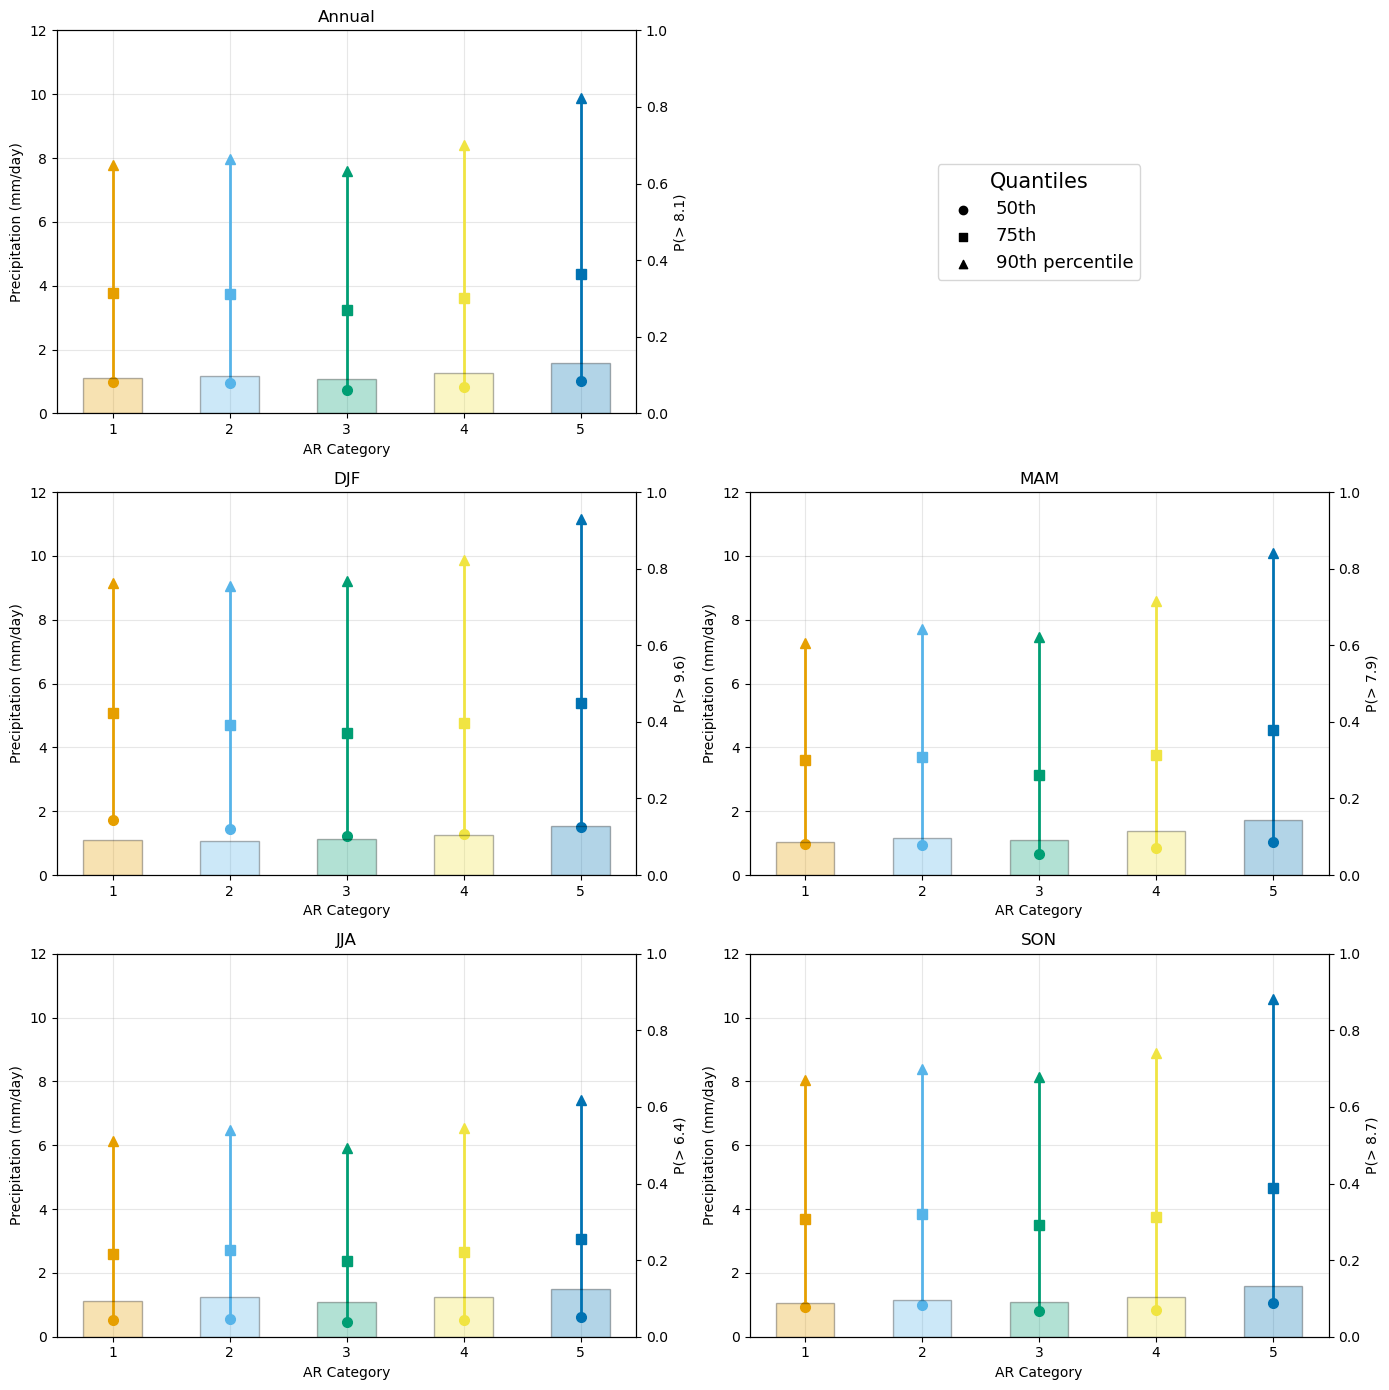

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# Load data
# -------------------
df = pd.read_csv("seasonal_precip_distributions.csv")
precip_arr_annual = np.load("precip_distributions.npy", allow_pickle=True)

categories = np.arange(1, len(precip_arr_annual) + 1)
seasons = ["DJF", "MAM", "JJA", "SON"]

# -------------------
# Color setup
# -------------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]
color_map = {c: colors[i] for i, c in enumerate(categories)}

quantile_markers = ['o', 's', '^']
quantile_labels = ['50th', '75th', '90th percentile']

# -------------------
# GLOBAL Y-LIMIT (IMPORTANT)
# -------------------
all_annual_vals = np.concatenate(precip_arr_annual)
all_seasonal_vals = df["precip"].values
all_vals = np.concatenate([all_annual_vals, all_seasonal_vals])

global_ymax = np.quantile(all_vals, 0.99)

# -------------------
# Create figure (3x2)
# -------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

# =========================================================
# 🔵 ANNUAL (axes[0])
# =========================================================
ax1 = axes[0]

quantiles = []
for arr in precip_arr_annual:
    q = np.quantile(arr, [0.5, 0.75, 0.9])
    quantiles.append(q)
quantiles = np.array(quantiles)

all_vals_annual = np.concatenate(precip_arr_annual)
threshold = np.quantile(all_vals_annual, 0.9)
exceedance = [np.mean(arr > threshold) for arr in precip_arr_annual]

for i, c in enumerate(categories):
    ax1.plot([c]*3, quantiles[i], color=color_map[c], linewidth=2)
    
    for j in range(3):
        ax1.plot(c, quantiles[i, j],
                 marker=quantile_markers[j],
                 color=color_map[c],
                 markersize=7,
                 linestyle='')

ax1.set_title("Annual")
ax1.set_xlabel("AR Category")
ax1.set_ylabel("Precipitation (mm/day)")
ax1.set_ylim(0, 12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(categories)

ax2 = ax1.twinx()
ax2.bar(categories, exceedance,
        color=[color_map[c] for c in categories],
        alpha=0.3, edgecolor='black', width=0.5)
ax2.set_ylim(0, 1)
ax2.set_ylabel(f"P(> {threshold:.1f})")

# =========================================================
# 🔲 LEGEND PANEL (axes[1])
# =========================================================
axes[1].axis("off")

for j, label in enumerate(quantile_labels):
    axes[1].scatter([], [], marker=quantile_markers[j], color='black', label=label)

axes[1].legend(
    title="Quantiles",
    loc="center",
    fontsize=13,
    title_fontsize=15
)

# =========================================================
# 🟢 SEASONAL PANELS
# =========================================================
for idx, season in enumerate(seasons):
    ax1 = axes[2 + idx]
    
    df_season = df[df["season"] == season]
    
    precip_arr = []
    for cat in categories:
        arr = df_season[df_season["category"] == cat]["precip"].values
        arr = arr[arr > 0]
        precip_arr.append(arr)
    
    # Quantiles
    quantiles = []
    for arr in precip_arr:
        if len(arr) > 0:
            q = np.quantile(arr, [0.5, 0.75, 0.9])
        else:
            q = [np.nan, np.nan, np.nan]
        quantiles.append(q)
    quantiles = np.array(quantiles)
    
    # Threshold
    all_vals_season = df_season["precip"].values
    all_vals_season = all_vals_season[all_vals_season > 0]
    threshold = np.quantile(all_vals_season, 0.9)
    
    exceedance = [
        np.mean(arr > threshold) if len(arr) > 0 else np.nan
        for arr in precip_arr
    ]
    
    # Plot
    for i, c in enumerate(categories):
        ax1.plot([c]*3, quantiles[i], color=color_map[c], linewidth=2)
        
        for j in range(3):
            ax1.plot(c, quantiles[i, j],
                     marker=quantile_markers[j],
                     color=color_map[c],
                     markersize=7,
                     linestyle='')
    
    ax1.set_title(season)
    ax1.set_xlabel("AR Category")
    ax1.set_ylabel("Precipitation (mm/day)")
    ax1.set_ylim(0, 12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(categories)
    
    ax2 = ax1.twinx()
    ax2.bar(categories, exceedance,
            color=[color_map[c] for c in categories],
            alpha=0.3, edgecolor='black', width=0.5)
    
    ax2.set_ylim(0, 1)
    ax2.set_ylabel(f"P(> {threshold:.1f})")

# -------------------
# Clean layout
# -------------------
plt.tight_layout()
plt.savefig("Supplementary_Figure3.pdf", dpi=300, bbox_inches="tight")
plt.show()